In [159]:
import pandas as pd
import numpy as np
import torch
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Loading Dataset

In [108]:
df = pd.read_csv('./dataset/insurance.csv')

In [109]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Data Quality

In [110]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [111]:
df.duplicated().sum()

np.int64(1)

In [112]:
df = df.drop_duplicates()

# Encoding

In [113]:
ordinal_encoder = OrdinalEncoder(categories=[['female', 'male'], ['yes', 'no']])
df[['sex', 'smoker']] = ordinal_encoder.fit_transform(df[['sex', 'smoker']])

In [114]:
df = pd.get_dummies(df, columns=['region'], dtype=int)

In [115]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0.0,27.900,0,0.0,16884.92400,0,0,0,1
1,18,1.0,33.770,1,1.0,1725.55230,0,0,1,0
2,28,1.0,33.000,3,1.0,4449.46200,0,0,1,0
3,33,1.0,22.705,0,1.0,21984.47061,0,1,0,0
4,32,1.0,28.880,0,1.0,3866.85520,0,1,0,0


# Train Test Split

In [185]:
X = df.drop(columns=['charges'])
y = df[['charges']]

In [186]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state = 42
)

# Feature Scaling

In [187]:
# Creating scalers
x_scaler = StandardScaler()
y_scaler = StandardScaler()

# Fitting training data
X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

y_train = y_scaler.fit_transform(y_train)
y_test = y_scaler.transform(y_test)   

# Vanilla Gradient Descent 

In [192]:
class LinearRegression:

    def __init__(self, lr=0.9, iterations=1000, tolerance=1e-6, patience=10):
        self.lr = lr
        self.iterations = iterations
        self.tolerance = tolerance
        self.patience = patience

        self.loss_history = []

        # for visualizations
        self.training_history = {}
        self.weight_history = []

    def mean_squared_error(self, y_hat, y):
        m = len(y)
        return (1 / (2 * m)) * np.sum((y_hat - y) ** 2)

    def fit(self, X, y):

        m, n = X.shape

        self.weights = np.zeros(n)
        self.bias = 0

        no_improvement = 0

        for i in range(self.iterations):

            # Forward pass
            y_hat = np.dot(X, self.weights) + self.bias

            # Calculate loss
            loss = self.mean_squared_error(y_hat, y)
            self.loss_history.append(loss)

            # Save weights
            self.weight_history.append(self.weights.copy())

            # Gradients
            dloss_dweights = (1 / m) * np.dot(X.T, y_hat - y)
            dloss_dbias = (1 / m) * np.sum(y_hat - y)

            # Parameter update
            self.weights -= self.lr * dloss_dweights
            self.bias -= self.lr * dloss_dbias

            # convergence based stopping
            if i > 0:
                loss_change = abs(
                    self.loss_history[-2] - self.loss_history[-1]
                )

                if loss_change < self.tolerance:
                    no_improvement += 1
                else:
                    no_improvement = 0

                if no_improvement >= self.patience:
                    print(f"Converged at iteration {i + 1}")
                    break

    def predict(self, X):
        predictions = np.dot(X, self.weights) + self.bias
        return predictions

In [204]:
model_gd = LinearRegression(
    lr=0.01,
    iterations=1000,
    tolerance=1e-6,
    patience=10
)

In [205]:
model_gd.fit(X_train, y_train.ravel())

Converged at iteration 481


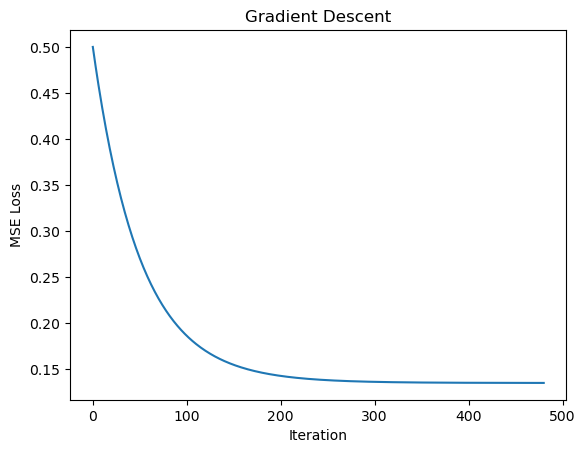

In [206]:
plt.plot(model_gd.loss_history)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Gradient Descent")
plt.show()

In [207]:
preds = model_gd.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, preds)
mse

0.2588935042404378

# GD with Momentum

In [ ]:
class LinearRegression_Momentum:
    def __init__(self, lr=0.01, iterations=1000, tolerance=1e-6, patience=20, beta = 0.9):
        self.lr = lr
        self.iterations = iterations
        self.tolerance = tolerance
        self.patience = patience
        self.beta = beta                # hyperparameter to assign weight to history
        self.V_t = 0                    # Previous Velocity
        self.loss_history = []

    # Loss Function
    def mse(self, y, y_hat):
        m = len(y)
        return (1/(2*m)) * np.sum((y_hat - y)**2)

    def fit(self, X, y):
        m, n = X.shape

        self.bias = 0
        self.weights = np.zeros(n)
        no_improvement = 0

        for epoch in range(self.iterations):
            y_hat = np.dot(X, self.weights) + self.bias

            loss = self.mse(y, y_hat)
            # saving loss
            self.loss_history.append(loss)  

            # convergence based stopping
            if epoch > 0:
                loss_change = abs(self.loss_history[-2] - self.loss_history[-1])

                if loss_change < self.tolerance:
                    no_improvement += 1

                if no_improvement > self.patience:
                    print(f"Converged at iteration {epoch + 1}")
                    break

                
            dloss_dweights = (1/m) * np.dot(X.T, y_hat-y)
            dloss_dbias = (1/m) * np.sum(y_hat - y)
            self.V_t = (self.beta * self.V_t) + (1 - self.beta)*dloss_dweights  # gradient descent with momentum

            self.weights -= self.lr * self.V_t
            self.bias -= self.lr * dloss_dbias


In [210]:
model_gd_momentum = LinearRegression_Momentum(
    lr=0.01,
    iterations=1000,
    tolerance=1e-6,
    patience=20,
    beta = 0.9
)

In [211]:
model_gd_momentum.fit(X_train,  y_train.ravel())

Converged at iteration 465


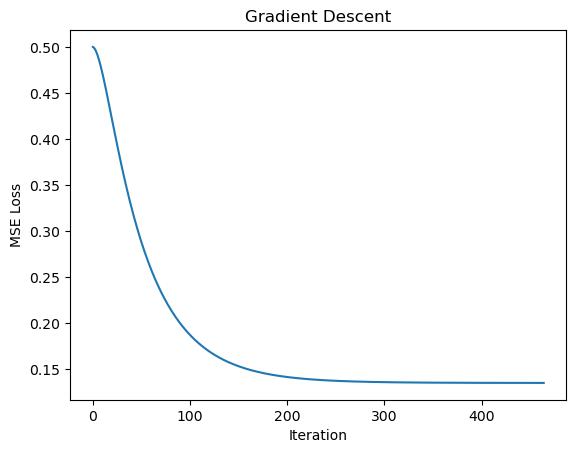

In [212]:
plt.plot(model_gd_momentum.loss_history)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Gradient Descent")
plt.show()

In [213]:
preds = model_gd.predict(X_test)

In [214]:
mse = mean_squared_error(y_test, preds)
mse

0.2588935042404378